#Αναστασία Λουκέρη 10975, Μαρία Ελένη Σαμαμίδου 11054
#ΜΕΡΟΣ Δ
##ΟΠΤΙΚΟΠΟΙΗΣΗ ΤΟΥ ΣΥΝΟΛΟΥ ΕΚΠΑΙΔΕΥΣΗΣ
Εισαγωγή Βιβλιοθηκών για οπτικοποίηση του συνόλου εκπαίδευσης:\
pandas & numpy: Για την ανάγνωση και επεξεργασία των δεδομένων (πίνακες).\
matplotlib & seaborn: Για τη δημιουργία των γραφημάτων.\
sklearn (Scikit-Learn): Περιλαμβάνει την τεχνική PCA για τη μείωση των διαστάσεων.\
Προκειμένου να οπτικοποιήσουμε τα features κάθε κλάσης, πρέπει να μειώσουμε τις διαστάσεις. Για αυτό εφαρμόζουμε Ανάλυση Κυρίων Συνιστωσών (PCA) διατηρώντας τα 2 (για δυσδιάστατη αναπαράσταση) και αντίστοιχα 3 (για τρισδιάσταση αναπαράσταση) πιο 'ισχυρά' features της κάθεμιας. Η τρισδιάστατη οπτικοποίηση μέσω της τεχνικής PCA αναδεικνύει με σαφήνεια την εσωτερική δομή του dataset, όπου η Κλάση 1 (μαύρο χρώμα) διαφοροποιείται πλήρως από τις υπόλοιπες, καταλαμβάνοντας έναν διακριτό και απομονωμένο χώρο στη δεξιά πλευρά του γραφήματος. Αυτή η χωρική απομάκρυνση υποδηλώνει ότι η συγκεκριμένη ομάδα διαθέτει μοναδικά και "ισχυρά" χαρακτηριστικά που την καθιστούν εύκολα αναγνωρίσιμη από τους αλγόριθμους ταξινόμησης. Αντίθετα, οι κλάσεις 2, 3, 4 και 5 εμφανίζουν μια ιδιαίτερα πυκνή συσσώρευση στην αριστερή πλευρά, δημιουργώντας ένα ενιαίο σύννεφο δεδομένων με εκτεταμένες περιοχές επικάλυψης (overlap). Έτσι, παρατηρείται ότι τα σημεία των κεντρικών ομάδων μοιράζονται κοινά όρια στον χώρο των κύριων συνιστωσών (PCA). Αυτό το σημείο αποτελεί τη μεγαλύτερη πρόκληση για την ταξινόμηση, καθώς τα δείγματα αυτών των ομάδων μοιράζονται παρόμοιες τιμές στις αρχικές στήλες του αρχείου datasetTV.csv, καθιστώντας τα όρια μεταξύ τους δυσδιάκριτα. Παρά την επικάλυψη αυτή, η υψηλή συγκέντρωση των σημείων και η απουσία διάσπαρτων outliers μαρτυρούν ένα συνεπές και στιβαρό dataset, όπου η επιτυχία των μοντέλων θα κριθεί στην ικανότητά τους να διαχωρίσουν τις λεπτές διαφορές εντός αυτής της κεντρικής, πολυπληθούς μάζας.        

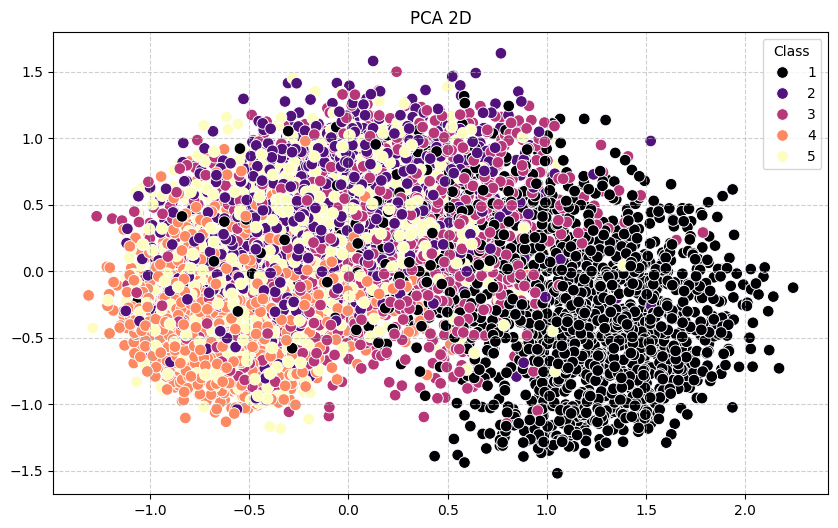

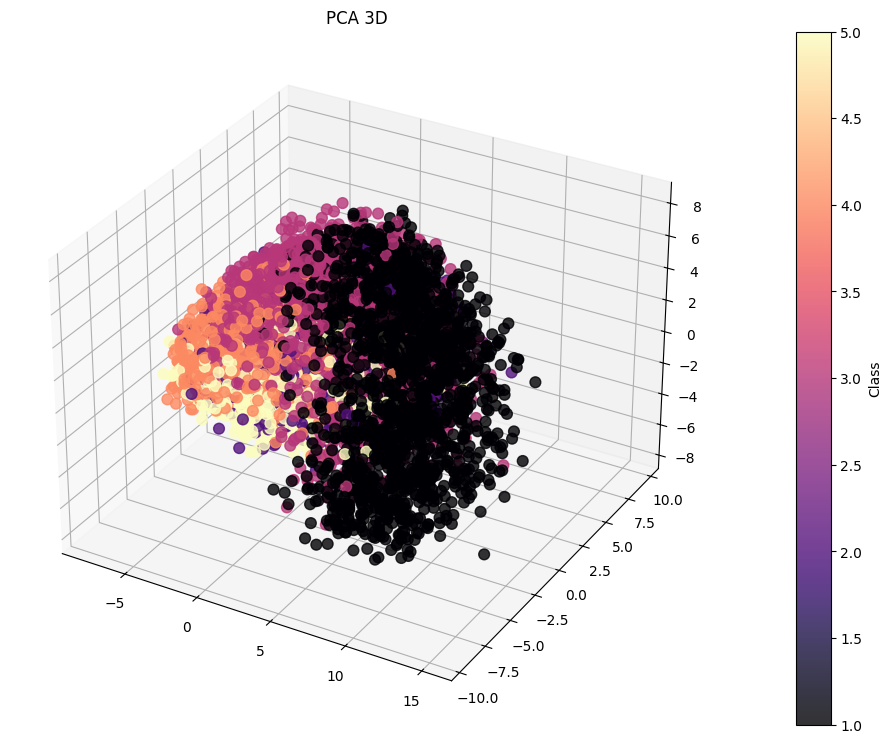

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

#  Φόρτωση δεδομένων
dataset = pd.read_csv('datasetTV.csv')

#  Διαχωρισμός σε χαρακτηριστικά και labels
X = dataset.iloc[:, :-1]  # Όλες οι στήλες εκτός της τελευταίας
y = dataset.iloc[:, -1]   # Η τελευταία στήλη με τις κατηγορίες

#  Κανονικοποίηση
# Απαραίτητο για να "φαίνονται" σωστά τα δεδομένα στο PCA
X_scaled = MinMaxScaler().fit_transform(X)

# Μείωση διαστάσεων σε 2 (για να μπορούμε να το σχεδιάσουμε)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Οπτικοποίηση
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='magma', s=70)

plt.title('PCA 2D')


plt.legend(title='Class')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
# Το Axes3D είναι απαραίτητο για 3D προβολές στο matplotlib
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

dataset = pd.read_csv('datasetTV.csv')

X = dataset.iloc[:, :-1].values  # Όλες οι στήλες εκτός από την τελευταία
y = dataset.iloc[:, -1].values   # Η τελευταία στήλη (τα labels)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#  Μείωση Διαστάσεων
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

#  Οπτικοποίηση 3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')


scatter = ax.scatter(
    X_pca_3d[:, 0],
    X_pca_3d[:, 1],
    X_pca_3d[:, 2],
    c=y,
    cmap='magma',
    s=60,            # Μέγεθος σημείων
    alpha=0.8        # Ελαφριά διαφάνεια για να φαίνονται τα σημεία από πίσω
)

ax.set_title('PCA 3D')
# Προσθήκη μπάρας χρωμάτων για να ξέρουμε ποιο χρώμα είναι ποιο label
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Class')

plt.show()

#ΠΡΟΕΠΕΞΕΡΓΑΣΙΑ ΔΕΔΟΜΕΝΩΝ - ΜΕΡΟΣ Α'
Το σύνολο δεδομένων στο οποίο θα πραγματοποιηθεί η εκπαίδευση του μοντέλου φορτώνεται στο πρόγραμμα μέσω της βιβλιοθήκης Numpy ως Numpy array και με array slicing διαχωρίζονται τα χαρακτηριστικά από τις ετικέτες.

Στην συνέχεια μέσω της βιβλιοθήκης scikit-learn το σύνολο δεδομένων διαχωρίζεται σε training set με αναλογία 80%-20%. Αυτό γίνεται ούτως ώστε να είναι εφικτή η αξιολόγηση του μοντέλου ως προς τα σφάλματα ταξινόμησης.
Τα χαρακτηριστικά του προβλήματος (μεγάλος αριθμός δειγμάτων και χαρακτηριστικών ανα δείγμα, έλλειψη γνώσης της φυσικής σημασίας των χαρακτηριστικών, χαρακτηριστικά που παίρνουν συνεχείς τιμές) καθιστούν την προεπεξεργασία των δεδομένων απαραίτητη.

**Κανονικοποίηση (Scaling)**: Πρόκειται για τον μαθηματικό σχηματισμό
\begin{align}
x_{scaled} = \frac{x - μ_x}{σ_x}
\end{align}
ο οποίος εξασφαλίζει ότι τα δεδομένα ακολουθούν Gaussian κατανομή με μηδενική μέση τιμή και μοναδιαία διασπορά (~N(0,1)). Η κανονικοποίηση ελαττώνει την μεροληψία ως προς τα χαρακτηριστικά, καθώς πλέον αυτά προέρχονται από την ίδια κατανομή. Όπως θα αναλυθεί παρακάτω, το αν η κανονικοποίηση είναι ωφέλιμη εξαρτάται από τον ταξινομητή που επιλέγεται.

**Ανάλυση Κύριων Συνιστωσών (PCA)**: Πρόκειται για μια μέθοδο γραμμικής μείωσης της διάστασης, της οποίας ο στόχος είναι η εύρεση συνιστωσών στα δεδομένα οι οποίες "αποτυπώνουν" την μεγαλύτερη διακύμανση αυτών.

Οι συνιστώσες που προκύπτουν από την διαδικασία αυτήν είναι μεταξύ τους ορθογώνιες (άρα και ασυσχέτιστες), με την πρώτη αυτών να είναι η ισχυρότερη (μέγιστη διακύμανση) και κάθε επόμενη να αποτυπώνει την υπολοιπόμενη διακύμανση από την προηγούμενη. Προφανώς για να είναι αμερόληπτη η ευ΄ρεση των συνιστωσών, θα πρέπει να έχει προηγηθεί κανονικοποίηση των δεδομένων.

Η μείωση της διάστασης έγκειται στην ελευθερία ως σχεδιαστές του μοντέλου να επιλέξουμε αριθμό συνιστωσών οι οποίες αποτυπώνουν ένα μόνο ποσοστό της διακύμανσης. Για το συγκεκριμένο πρόβλημα επιλέξαμε το 70%, έτσι ώστε να είναι σημαντική η μείωση της διάστασης των χαρακτηριστικών από 224 σε 88.


In [ ]:
# Importing the data - separating features from labels
import numpy as np
from pandas.core.common import random_state

training_set = np.loadtxt('datasetTV.csv', delimiter=',')
features = training_set[:, 0:224]
labels = training_set[:, 224]

# Splitting -> training and test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    features, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [ ]:
# Scaling the training and testing features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

# Performing PCA on training and testing features
from sklearn.decomposition import PCA
pca = PCA(
    n_components=0.7
)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# Display size of the training data after preprocessing
print(X_train.shape)
print(X_test.shape)

(6994, 88)
(1749, 88)


In [ ]:
# Import the requirements for the model evaluation
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

#ΠΕΡΙΓΡΑΦΗ ΤΑΞΙΝΟΜΗΤΩΝ - ΜΕΡΟΣ Α'
Στην παρούσα ενότητα αναλύονται και δοκιμάζονται διάφοροι ταξινομητές. Η εκπαίδευση γίνεται στο training set και η αξιολόγηση στο test set, όπως αυτά προέκυψαν από το αρχικό σύνολο δεδομένων στο κομμάτι της εισαγωγής.

Η αξιολόγηση γίνεται σύμφωνα με το accuracy score της sci-kit learn, όμως παρατίθεται το classification report και το confusion matrix για πληρέστερη ερμηνεία του αποτελέσματος.
###Ταξινομητής Μέγιστης Πιθανοφάνειας (Maximum Likelihood Classifier)
Ο Ταξινομητής Μέγιστης Πιθανοφάνειας αποτελεί μια από τις κλασικότερες επιλογές ταξινομητών και αποδεικνύεται ότι είναι αρκετά λειτουργικός στην περίπτωση ενός μεγάλου συνόλου δεδομένων.

Η υπόθεση πάνω στην οποία στηρίζεται η λειτουργία του, είναι ότι τα δεδομένα ακολουθούν πολυμεταβλητή gaussian κατανομή, πράγμα που αποτελεί ακριβώς το inductive bias που εισάγει ο συγκεκριμένος ταξινομητής. Έχοντας υποθέσει ότι η συνάρτηση πυκνότητας πιθανότητας των δεδομένων για όλες τις κλάσεις είναι gaussian, υπολογίζει παραμετρικά τις τιμές των παραμέτρων (διάνυσμα μέσων τιμών και πίνακας συμμεταβλητότητας των χαρακτηριστικών) οι οποίες μεγιστοποιούν την συνάρτηση πιθανοφάνειας.

Έτσι, έχοντας εκτιμήσει με τον συγκεκριμένο τρόπο την σ.π.π. των δεδομένων, μπορεί δεδομένου των τιμών των χαρακτηριστικών να υπολογίσει την εκ των υστέρων πιθανότητα ένα δείγμα να ανήκει σε μια συγκεκριμένη κλάση, στηριζόμενος στον κανόνα του Bayes.
###Αποτελέσματα
Βάσει των αποτελεσμάτων, το μοντέλο παρουσιάζει συνολική ακρίβεια περίπου 85.5%, γεγονός που υποδηλώνει καλή γενική απόδοση στο πρόβλημα ταξινόμησης των 5 κλάσεων. Το classification report δείχνει ότι οι κλάσεις 1 και 3 ταξινομούνται εξαιρετικά καλά, με πολύ υψηλά precision και recall (≈0.93–0.97) και κλάση 4 έχει ισορροπημένη και καλή απόδοση, κάτι που σημαίνει ότι το μοντέλο αναγνωρίζει αξιόπιστα τα δείγματα αυτών των κατηγοριών και κάνει λίγα λάθη. Οι κλάσεις 2 και 5 εμφανίζουν χαμηλότερες επιδόσεις, ιδιαίτερα στο recall της κλάσης 2 (0.69), υποδηλώνοντας ότι αρκετά δείγματα αυτής της κλάσης συγχέονται με άλλες, κυρίως με την κλάση 5, όπως φαίνεται και στο confusion matrix. Οι macro και weighted averages είναι παρόμοιες, κάτι που δείχνει ότι το dataset είναι σχετικά ισορροπημένο. Η απόδοση του ταξινομητή είναι αρκετά ικανοποιητική, έχοντας βέβαια ακόμη πειρθώριο βελτίωσης.

In [ ]:
# Training MLC
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

#Evaluating MLC
y_b1 = qda.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_b1))
print(classification_report(y_test, y_b1))
print(confusion_matrix(y_test, y_b1))

Accuracy: 0.8553459119496856
              precision    recall  f1-score   support

         1.0       0.96      0.97      0.97       354
         2.0       0.74      0.69      0.72       344
         3.0       0.93      0.93      0.93       351
         4.0       0.91      0.89      0.90       343
         5.0       0.73      0.80      0.76       357

    accuracy                           0.86      1749
   macro avg       0.86      0.85      0.86      1749
weighted avg       0.86      0.86      0.86      1749

[[343   5   5   1   0]
 [  1 238   6   8  91]
 [  8   3 325  14   1]
 [  0  13  13 305  12]
 [  4  61   1   6 285]]


#k-Nearest Neighbors
Ο Ταξινομητής των  k -Nearest Neighbors ( k NN) αποτελεί έναν από τους πιο διαισθητικούς αλγορίθμους και ανήκει στην κατηγορία της μη παραμετρικής μάθησης.

Το inductive bias που εισάγει ο συγκεκριμένος ταξινομητής είναι η υπόθεση της τοπικότητας, δηλαδή η παραδοχή ότι δείγματα που βρίσκονται κοντά στον χώρο των χαρακτηριστικών είναι πολύ πιθανό να ανήκουν στην ίδια κλάση. Ως μη-παραμετρικός, ο kNN δεν προϋποθέτει κάποια συγκεκριμένη μορφή για τη συνάρτηση πυκνότητας πιθανότητας των δεδομένων, γεγονός που του επιτρέπει να προσαρμόζεται σε πολύπλοκα και μη γραμμικά πρότυπα χωρίς την εκτίμηση παραμέτρων.

Η λειτουργία του βασίζεται στον υπολογισμό μιας συνάρτησης απόστασης (συνήθως της Ευκλείδειας) μεταξύ του άγνωστου δείγματος και όλων των διαθέσιμων δειγμάτων εκπαίδευσης. Η απόφαση λαμβάνεται με βάση την αρχή της πλειοψηφίας, δηλαδη το δείγμα κατατάσσεται στην κλάση που επικρατεί ανάμεσα στους  k  πλησιέστερους γείτονές του. Επειδή η ο ταξινομτής αυτός βασίζεται στην απόσταση, είναι αναγκαία η κανονικοποίηση των δεδομένων.

Η επιλογή του  k  παίζει σημαντικό ρόλο στην αποδοτικότητα του ταξινομητή, καθώς για μεγάλες τιμές του μπορεί να οδηγηθούμε σε overfitting και μοντέλα εαυίσθητα στον θόρυβο, ενώ για μικρές τιμές του μπορεί τα όρια απόφασης να μην είναι αντιπροσωπευτικά των δεδομένων (underfitting).

Υπερπαράμετροι:
* n_neighbors=7: ο αριθμός των κοντινότερων γειτόνων που λαμβάνεται υπόψιν για την ταξινόμηση.
* weights='distance': ορίζει την συνεισφορά του κάθε γείτονα στην απόφαση (με distance, οι πιο κοντινοί γείτονες έχουν μεγαλύτερη επιρροή από τους πιο μακρινούς)
* metric='minkowski': τρόπος υπολογισμού της απόστασης των γειτόνων (η minkowski αντιστοιχεί στην Ευκλείδεια απόσταση)

### Αποτελέσματα:
Ο k-NN ταξινομητής με k=7 και ευκλείδεια απόσταση επιτυγχάνει συνολική ακρίβεια περίπου 83.6%, ελαφρώς χαμηλότερη από εκείνη του maximum likelihood ταξινομητή, γεγονός που δείχνει ότι, συνολικά, το προηγούμενο μοντέλο γενικεύει καλύτερα στο συγκεκριμένο πρόβλημα. Όπως και πριν, οι κλάσεις 1, 3 και 4 ταξινομούνται με πολύ καλή απόδοση, με υψηλά precision και recall, επιβεβαιώνοντας ότι οι συγκεκριμένες κλάσεις είναι καλά διαχωρίσιμες στον χώρο των χαρακτηριστικών. Αντίθετα, όπως φαίνεται πάλι στο confusion matrix, η κλάση 2 συγχέεται σε μεγάλο ποσοστό των περιπτώσεων με την κλάση 5. Ο συγκεκριμένος ταξινομητής εμφανίζει μεγάλη ευαισθησία σε τοπικές επικαλύψεις των κλάσεων, λόγω της απόφασης βάσει γειτόνων και αποστάσεων. Συνολικά, ο k-NN αποδίδει ικανοποιητικά, αλλά φαίνεται λιγότερο σταθερός στις πιο δύσκολα διαχωρίσιμες κλάσεις.

In [ ]:
# Training kNN on preprocessed data
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors=7,      # default: 5 nearest neighbors
    weights='distance', # optional: closer points = more influence
    metric='minkowski',  # Euclidean distance
)
knn.fit(X_train, y_train)

# Evaluating kNN
y_b2 = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_b2))
print(classification_report(y_test, y_b2))
print(confusion_matrix(y_test, y_b2))

Accuracy: 0.8359062321326473
              precision    recall  f1-score   support

         1.0       0.92      0.97      0.95       354
         2.0       0.73      0.58      0.65       344
         3.0       0.92      0.91      0.92       351
         4.0       0.94      0.92      0.93       343
         5.0       0.67      0.80      0.73       357

    accuracy                           0.84      1749
   macro avg       0.84      0.84      0.83      1749
weighted avg       0.84      0.84      0.83      1749

[[343   2   8   1   0]
 [  5 199   7   6 127]
 [ 22   1 319   8   1]
 [  0   8   8 315  12]
 [  1  62   3   5 286]]


#Λογιστική Παλινδρόμηση (Logistic Regression)
Η Λογιστική Παλινδρόμηση για πολυκατηγορική ταξινόμηση υπάγεται στην κατηγορία των διακριτικών προμπαμπιλιστικών μοντέλων. Για καθεμία από τις 5 κλάσεις ορίζεται μια γραμμική συνάρτηση (γραμμικός συνδυασμός των features), και έπειτα αυτές μετατρέπονται σε πιθανότητες (θετικές ποσότητες που αθροίζουν στην μονάδα) μέσω της συνάρτησης Softmax.
\begin{align}
P(ω_i|x) = \frac{exp(w_i^T)}{\sum{exp(w_i^Tx)}}
\end{align}
Τα βάρη προκύπτουν από την εκπαίδευση με Maximum Likelihood, SGD και συνάρτηση κόστους την Cross-Entropy Loss. Η πρόβλεψη ταξινομεί το εισερχόμενο δείγμα x στην τάξη με την μέγιστη  εκ των υστέρων πιθανότητα.
###Αποτελέσματα
Η λογιστική παλινδρόμηση παρουσιάζει χαμηλη συνολική ακρίβεια (≈79.2%), γεγονός που υποδηλώνει ότι το γραμμικό αυτό μοντέλο δυσκολεύεται να αποτυπώσει πλήρως τη δομή του προβλήματος. Αν και η κλάση 1 εξακολουθεί να ταξινομείται με πολύ καλή απόδοση, παρατηρείται γενικότερη πτώση σε precision και recall. Ιδιαίτερα η κλάση 2 εμφανίζει ξανά χαμηλό recall (0.63), ενώ το confusion matrix δείχνει έντονη σύγχυση με την κλάση 5, αλλά και με άλλες κλάσεις. Οι κλάσεις 3 και 4 παρουσιάζουν μέτρια αλλά σταθερή απόδοση, χωρίς όμως να φτάνουν τα επίπεδα των προηγούμενων μοντέλων και φαίνεται ότι η λογιστική παλινδρόμηση είναι λιγότερο ικανή να χειριστεί μη γραμμικά όρια απόφασης στον χώρο των χαρακτηριστικών. Συνολικά τα αποτελέσματα υποδεικνύουν ότι το πρόβλημα απαιτεί πιο ευέλικτα μοντέλα καθώς η απλή γραμμική υπόθεση της λογιστικής παλινδρόμησης περιορίζει την τελική απόδοση.

In [ ]:
# Train the model
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)

# Evaluate the model
y_b4 = lr.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_b4))
print(classification_report(y_test, y_b4))
print(confusion_matrix(y_test, y_b4))

Accuracy: 0.7924528301886793
              precision    recall  f1-score   support

         1.0       0.92      0.95      0.93       354
         2.0       0.72      0.63      0.67       344
         3.0       0.82      0.82      0.82       351
         4.0       0.82      0.85      0.84       343
         5.0       0.67      0.71      0.69       357

    accuracy                           0.79      1749
   macro avg       0.79      0.79      0.79      1749
weighted avg       0.79      0.79      0.79      1749

[[335   2  14   2   1]
 [  1 218  22  11  92]
 [ 16  11 288  23  13]
 [  5   8  19 291  20]
 [  7  63   7  26 254]]


# Random Forests
Τα Random Forests είναι μέθοδοι ensemble που βασίζονται στον συνδυασμό πολλών decision trees για ταξινόμηση ή παλινδρόμηση. Κάθε δέντρο εκπαιδεύεται σε ένα διαφορετικό bootstrap δείγμα των δεδομένων (bagging), ενώ σε κάθε κόμβο εξετάζεται μόνο ένα τυχαίο υποσύνολο χαρακτηριστικών. Αυτή η τυχαιότητα μειώνει τη συσχέτιση μεταξύ των δέντρων και περιορίζει το overfitting.

Στην πολυκατηγορική ταξινόμηση, κάθε δέντρο παράγει μία πρόβλεψη κλάσης και η τελική απόφαση του random forest προκύπτει μέσω πλειοψηφικής ψήφου. Τα Random Forests είναι ανθεκτικά στον θόρυβο, αποδίδουν καλά χωρίς έντονη παραμετροποίηση και μπορούν να χειριστούν δεδομένα υψηλής διάστασης (για τον λόγο αυτό εκπαιδεύονται στα αρχικά και όχι στα preprocessed δεδομένα)

##### Υπερπαράμετροι:
- n_estimators: αριθμός των decision trees που περιλαμβάνει το random forest
- criterion: ορίζει το μέτρο ποιότητας για το split των κόμβων (gini ευνοεί τα καθαρότερα nodes)
- max_features: καθορίζει πόσα χαρακτηριστικά εξετάζονται σε κάθε split (το sqrt μειώνει τη συσχέτιση μεταξύ των δέντρων και βοηθά στον έλεγχο του overfitting)
- random_state: σπόρος τυχαιότητας για αναπαραγωγίσιμα αποτελέσματα.
###Αποτελέσματα
Ο ταξινομητής Random Forest παρουσιάζει ακρίβεια περίπου 84.9%, τοποθετώντας την απόδοσή του πολύ κοντά σε εκείνη του maximum likelihood. Η πολύ καλή απόδοση στις κλάσεις 1 και 3 (f1-score ≥ 0.91) δείχνει ότι το μοντέλο εκμεταλλεύεται αποτελεσματικά μη γραμμικές σχέσεις και αλληλεπιδράσεις μεταξύ των 224 χαρακτηριστικών. Ωστόσο, όπως και στους προηγούμενους ταξινομητές, οι κλάσεις 2 και 5 παραμένουν οι πιο απαιτητικές, με εμφανή σύγχυση μεταξύ τους στο confusion matrix. Συνολικά, ο Random Forest επιτυγχάνει καλή ισορροπία και ευρωστία, και επιλύει ικανοποιητικά το συγκεκριμένο πρόβλημα.

In [ ]:
# Train the model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=270,
    criterion='gini',
    max_features='sqrt',
    random_state=42,
)
model.fit(x_train, y_train)

# Evaluate the model
y_b7= model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_b7))
print(classification_report(y_test, y_b7))
print(confusion_matrix(y_test, y_b7))

Accuracy: 0.8490566037735849
              precision    recall  f1-score   support

         1.0       0.94      0.98      0.96       354
         2.0       0.75      0.69      0.72       344
         3.0       0.90      0.93      0.91       351
         4.0       0.91      0.88      0.89       343
         5.0       0.74      0.76      0.75       357

    accuracy                           0.85      1749
   macro avg       0.85      0.85      0.85      1749
weighted avg       0.85      0.85      0.85      1749

[[347   2   4   1   0]
 [  6 238  10   8  82]
 [  9   3 326  12   1]
 [  1   8  19 301  14]
 [  6  65   5   8 273]]


#AdaBoost
Ο AdaBoost  είναι μια μέθοδος ensemble που συνδυάζει πολλούς αδύναμους ταξινομητές (συνήθως decision stumps) για να δημιουργήσει έναν ισχυρό ταξινομητή. Στηρίζεται στην εκπαίδευση μοντέλων, όπου κάθε νέο μοντέλο δίνει μεγαλύτερη έμφαση στα προηγουμένως λανθασμένα ταξινομημένα δείγματα μέσω προσαρμογής των βαρών των δειγμάτων.

Κάθε ταξινομητής λαμβάνει ένα βάρος που εξαρτάται από την ακρίβειά του και η τελική πρόβλεψη προκύπτει από σταθμισμένη ψηφοφορία. Ο AdaBoost μπορεί να επιτύχει πολύ υψηλή ακρίβεια και ομοίως με τα Random Forests λειτουργεί καλύτερα όταν εισάγονται τα αρχικά και όχι τα preprocessed δεδομένα.

##### Υπερπαράμετροι:
- max_depth=5: το μέγιστο βάθος του δέντρου. Με βάθος 5, το δέντρο κάνει έως και 5 διακλαδώσεις μέχρι να λάβει απόφαση
- min_samples_leaf=40: ελάχιστος αριθμός δειγμάτων σε κάθε φύλλο του δέντρου, συμβάλλει στην αποφυγή του overfitting
- random_state=42: σπόρος τυχαιότητας για αναπαραγωγισιμότητα των αποτελεσμάτων
- estimator=base_tree: ως βασική μονάδα εκπαίδευσης εισάγεται το decision tree
- n_estimators=180: αριθμός των διαδοχικών γύρων εκπαίδευσης. Το μοντέλο θα φτιάξει 180 δέντρα το ένα μετά το άλλο, όπου κάθε επόμενο δέντρο θα προσπαθεί να διορθώσει τα λάθη των προηγούμενων.
- learning_rate=0.12: καθορίζει πόσο έντονα θα επηρεάζει κάθε δέντρο το τελικό αποτέλεσμα. Χαμηλό learning rate σημαίνει ότι το μοντέλο μαθαίνει πιο αργά και συντηρητικά, κάτι που συνήθως απαιτεί περισσότερους n_estimators, αλλά οδηγεί σε καλύτερη γενίκευση
###Αποτελέσματα
Ο ταξινομητής AdaBoost παρουσιάζει συνολική ακρίβεια περίπου 83.6%, συγκρίσιμη με εκείνη του k-NN και ελαφρώς χαμηλότερη από τον Random Forest και τον ML. Η πολύ υψηλή απόδοση στην κλάση 1 (f1-score ≈ 0.96) δείχνει ότι το boosting ενισχύει αποτελεσματικά τους ασθενείς ταξινομητές σε καλά διαχωρίσιμες κλάσεις. Παρόμοια, οι κλάσεις 3 και 4 εμφανίζουν και εδώ ισχυρή και σταθερή συμπεριφορά. Οι κλάσεις 2 και 5 παραμένουν και εδώ οι πιο δύσκολες, με έντονη αμφίδρομη σύγχυση όπως φαίνεται στο confusion matrix, στοιχείο που εμφανίζεται συστηματικά σε όλους τους ταξινομητές. Σε σύγκριση με τον Random Forest, ο AdaBoost φαίνεται πιο ευαίσθητος σε δύσκολα ή θορυβώδη δείγματα, κάτι αναμενόμενο λόγω της διαδοχικής έμφασης στα λάθη.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base_tree = DecisionTreeClassifier(
    max_depth=5,      # decision stump
    min_samples_leaf=50,
    random_state=42
)

ada = AdaBoostClassifier(
    estimator=base_tree,   # weak learner
    n_estimators=180,      # number of boosting rounds
    learning_rate=0.15, # contribution of each weak learner
    random_state=42
)

# Train and evaluate
ada.fit(x_train, y_train)
y_b8 = ada.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_b8))
print(classification_report(y_test, y_b8))
print(confusion_matrix(y_test, y_b8))

Accuracy: 0.8359062321326473
              precision    recall  f1-score   support

         1.0       0.97      0.96      0.96       354
         2.0       0.71      0.70      0.70       344
         3.0       0.92      0.89      0.91       351
         4.0       0.92      0.87      0.90       343
         5.0       0.69      0.76      0.72       357

    accuracy                           0.84      1749
   macro avg       0.84      0.84      0.84      1749
weighted avg       0.84      0.84      0.84      1749

[[339   2  10   0   3]
 [  1 240   6   4  93]
 [  9   4 314  17   7]
 [  1  12  11 299  20]
 [  1  81   1   4 270]]


#ΠΡΟΕΠΕΞΕΡΓΑΣΙΑ ΔΕΔΟΜΕΝΩΝ - ΜΕΡΟΣ Β'

Η διαδικασία φόρτωσης και προεπεξεργασίας των δεδομένων είναι το κρισιμότερο στάδιο, καθώς διασφαλίζει ότι οι αλγόριθμοι/ταξινομητές θα λάβουν τα δεδομένα σε μορφή που μπορούν να επεξεργαστούν αποτελεσματικά.
Ξεκινάει με τη χρήση της βιβλιοθήκης Pandas για την ανάγνωση των αρχείων datasetTV.csv και datasetTest.csv. Τα δεδομένα εκπαίδευσης διαχωρίζονται αμέσως σε δύο μέρη: στον πίνακα χαρακτηριστικών $X$, που περιλαμβάνει τα δεδομένα που θα χειριστούμε και στο διάνυσμα στόχου $y$, που περιέχει την ετικέτα της κλάσης.Η προεπεξεργασία/προετοιμασία των δεδομένων συμβαίνει μέσα στο Pipeline, το οποίο εκτελεί τρία διαδοχικά βήματα:
* Κανονικοποίηση (MinMaxScaler): Επειδή το dataset μπορεί να περιέχει στήλες με πολύ διαφορετικές κλίμακες (π.χ. μία στήλη με τιμές 0-1 και μία άλλη με 1000-5000), ο Scaler μετατρέπει τα πάντα στο διάστημα $[0, 1]$. Χωρίς αυτό, το SVM και το Νευρωνικό Δίκτυο (MLP) θα έδιναν λανθασμένη βαρύτητα στις μεγαλύτερες τιμές, αγνοώντας τις μικρότερες.
 * Μείωση Διαστάσεων (PCA): Με την παράμετρο n_components=0.8, ο αλγόριθμος αναλύει τις συσχετίσεις μεταξύ των στηλών και συμπυκνώνει την πληροφορία. Κρατάει μόνο τις "κύριες συνιστώσες" που αντιπροσωπεύουν το 80% της συνολικής διακύμανσης, εξαλείφοντας τον περιττό θόρυβο που θα μπορούσε να οδηγήσει σε overfitting.
 * Στρατηγική Επαλήθευσης (StratifiedKFold): Κατά την προετοιμασία της εκπαίδευσης, το dataset χωρίζεται σε 5 τμήματα (folds). Η επιλογή του "Stratified" είναι κομβική, καθώς διασφαλίζει ότι κάθε τμήμα έχει την ίδια αναλογία κλάσεων (π.χ. 20% από κάθε κλάση), εμποδίζοντας το μοντέλο από το να εκπαιδευτεί μεροληπτικά υπέρ μιας συγκεκριμένης ομάδας.

# ΠΕΡΙΓΡΑΦΗ ΤΑΞΙΝΟΜΗΤΩΝ - ΜΕΡΟΣ Β'
###Multi-Layer Perceptron
Αποτελείται από το επίπεδο εισόδου, ένα κρυφό επίπεδο και το επίπεδο εξόδου όπου γίνεται και η ταξινόμηση. \
Ανάλυση Υπερπαραμέτρων:

*   hidden_layer_sizes=[(400,)] : Ορίζει την αρχιτεκτονική του δικτύου, δηλαδή ένα κρυφό επίπεδο με 400 νευρώνες.
*   activation='relu' : Η συνάρτηση ενεργοποίησης καθορίζει εάν ένας νευρώνας θα πυροδοτηθεί (δηλαδή εάν θα μεταβιβάσει σήμα στον επόμενο νευρώνα) ή όχι. Μαθηματικά ορίζεται ως $f(x) = \max(0, x)$. Επιτρέπει στο δίκτυο να μαθαίνει μη γραμμικές σχέσεις και λύνει το πρόβλημα του vanishing gradient.
* solver='adam' : Είναι ο αλγόριθμος που αποφασίζει πώς θα αλλάξουν τα βάρη των νευρώνων ώστε να μειωθεί το σφάλμα της πρόβλεψης. Προσαρμόζει τον ρυθμό μάθησης για κάθε βάρος ξεχωριστά  ώστε να βρει το ολικό ελάχιστο της συνάρτησης σφάλματος.
* learning_rate_init=0.001 : Είναι το μέγεθος του βήματος που κάνει ο αλγόριθμος Adam.
* max_iter=1055 :
Καθορίζει πόσες φορές (εποχές/epochs) το νευρωνικό δίκτυο θα περάσει ολόκληρο το dataset από μέσα του για να μάθει.
###Αποτελέσματα MLP
Η ανάλυση των αποτελεσμάτων του MLP Classifier αποκαλύπτει μια ισορροπημένη και ρεαλιστική εικόνα της απόδοσης του μοντέλου, με τη συνολική ακρίβεια (accuracy) στο τελευταίο fold να ανέρχεται στο 86%.

Ο Confusion Matrix αναδεικνύει την κύρια πρόκληση του νευρωνικού δικτύου: τη δυσκολία πλήρους διαχωρισμού μεταξύ των κλάσεων 2 και 5. Συγκεκριμένα, η Κλάση 2 παρουσιάζει το χαμηλότερο recall (0,71), καθώς 75 δείγματα ταξινομήθηκαν λανθασμένα ως Κλάση 5. Παράλληλα, παρατηρείται και η αντίστροφη σύγχυση, με 56 δείγματα της Κλάσης 5 να ταξινομούνται ως Κλάση 2, γεγονός που επιβεβαιώνει την οπτική επικάλυψη των χαρακτηριστικών τους.

Αντιθέτως, οι κλάσεις 1, 3 και 4 επιτυγχάνουν υψηλά ποσοστά επιτυχίας (recall 0,97, 0,92 και 0,89 αντίστοιχα), καθώς τα χαρακτηριστικά τους παραμένουν πιο διακριτά στον χώρο των κύριων συνιστωσών. Η συνολική απόδοση του 86% στο fold αξιολόγησης αποτελεί μια αξιόπιστη εκτίμηση για την ικανότητα του μοντέλου να ανταποκρίνεται σε νέα δεδομένα, υποδεικνύοντας ότι το μοντέλο έχει αποφύγει την έντονη υπερεκπαίδευση και διατηρεί καλή γενικευτική ικανότητα.

###Naive Bayes
Βασίζεται στο Θεώρημα του Bayes, το οποίο επιτρέπει στον υπολογιστή να υπολογίσει την πιθανότητα να ανήκει ένα δείγμα σε μια κλάση, δεδομένων των χαρακτηριστικών του.Η μαθηματική διατύπωση είναι:$$P(C|x) = \frac{P(x|C) \cdot P(C)}{P(x)}$$Όπου:
* $P(C|x)$: Η πιθανότητα να ανήκει το δείγμα στην κλάση $C$ (π.χ. Κλάση 1), δεδομένων των δεδομένων $x$.
* $P(x|C)$: Η πιθανότητα να παρατηρήσουμε αυτά τα δεδομένα, αν γνωρίζουμε ότι ανήκουν στην κλάση $C$.
* $P(C)$: Η γενική πιθανότητα εμφάνισης της κλάσης $C$ στο dataset (Prior probability). \
Ο αλγόριθμος απλώς υπολογίζει τη μέση τιμή και τη διακύμανση κάθε στήλης. Μόλις γίνουν αυτοί οι υπολογισμοί, το μοντέλο είναι έτοιμο.
###Αποτελέσματα Naive Bayes
Η ανάλυση των αποτελεσμάτων του Naive Bayes αποκαλύπτει τους περιορισμούς του συγκεκριμένου μοντέλου, με τη μέγιστη ακρίβεια στο cross-validation να φτάνει το 77,52% και την ακρίβεια στο τελευταίο fold να περιορίζεται στο 77%. Επειδή ο Naive Bayes υποθέτει ότι κάθε χαρακτηριστικό είναι ανεξάρτητο, αδυνατεί να κατανοήσει τις πολύπλοκες σχέσεις που συνδέουν τις κλάσεις 2 και 5, με αποτέλεσμα η ακρίβεια (accuracy) στην Κλάση 2 να πέφτει στο 56,98%. Ο Confusion Matrix επιβεβαιώνει αυτό το πρόβλημα, δείχνοντας ότι 100 δείγματα της Κλάσης 2 μπερδεύτηκαν και ταξινομήθηκαν λανθασμένα ως Κλάση 5 (ενώ αντίστοιχα 66 δείγματα της Κλάσης 5 ταξινομήθηκαν ως Κλάση 2). Ωστόσο, το μοντέλο παραμένει πολύ ισχυρό στην Κλάση 1 με accuracy 91,50%, γεγονός που αποδεικνύει ότι η κλάση αυτή είναι η πλέον διακριτή στατιστικά για τον συγκεκριμένο αλγόριθμο.
###SVM με RBF πυρήνα
Ο SVM προσπαθεί να βρει το βέλτιστο περιθώριο (margin), δηλαδή τη μεγαλύτερη δυνατή απόσταση ανάμεσα στις κλάσεις. Επειδή τα δεδομένα (όπως είδαμε στο 3D plot) δεν χωρίζονται με μια απλή ευθεία γραμμή, ο RBF kernel επιτρέπει στο μοντέλο να δημιουργήσει μη γραμμικά και καμπύλα σύνορα.
Ο RBF Kernel υπολογίζει την εγγύτητα ή την ομοιότητα μεταξύ δύο σημείων $x_1$ και $x_2$. Ο τύπος του είναι:$$K(x_1, x_2) = \exp\left(-\gamma \cdot \|x_1 - x_2\|^2\right)$$
* Απόσταση: Όσο πιο κοντά είναι δύο σημεία στον χώρο, τόσο μεγαλύτερη είναι η τιμή του Kernel (πλησιάζει το 1).
 * Ακτινική Δομή: Η ονομασία "Radial" (Ακτινική) προέρχεται από το γεγονός ότι η επίδραση κάθε σημείου απλώνεται κυκλικά γύρω του, σαν μια καμπάνα (Gaussian distribution). \
 Aντιστοιχίζει τα δεδομένα σε έναν χώρο όπου κάθε δείγμα έχει άπειρο αριθμό χαρακτηριστικών που πλέον τα καθιστά γραμμικώς διαχωρίσιμα. Χρησιμοποιεί το Kernel Trick: υπολογίζει απευθείας την "ομοιότητα" (εσωτερικό γινόμενο) των σημείων στον αρχικό χώρο, αλλά το αποτέλεσμα είναι σαν να είχε γίνει ο υπολογισμός στις άπειρες διαστάσεις.
 * gamma='scale' : Καθορίζει πόσο "μακριά" φτάνει η επιρροή ενός μόνο δείγματος. Η τιμή 'scale' υπολογίζει αυτόματα την τιμή βάσει της διακύμανσης των δεδομένων ($1 / (n\_features \cdot X.var())$).
 * C=1.5 : Η παράμετρος regularization. Ελέγχει την ισορροπία ανάμεσα στη σωστή ταξινόμηση των δεδομένων εκπαίδευσης και τη διατήρηση ενός απλού συνόρου, για αποφυγή overfitting και καλύτερη γενίκευση στο άγνωστο datasetTest.csv. Tο μοντέλο είναι πιο ανεκτικό σε μικρά λάθη κατά την εκπαίδευση και άρα πρόκειται για μέθοδο Soft Margin.
###Αποτελέσματα SVM με RBF πυρήνα
Η ανάλυση των αποτελεσμάτων του SVM (Custom RBF) επιβεβαιώνει ότι πρόκειται για τον βέλτιστο ταξινομητή, καθώς πέτυχε τη μέγιστη ακρίβεια 89,07% στο cross-validation και 89% στο τελευταίο fold αξιολόγησης. Στις κλάσεις 1, 3 και 4, το Precision κυμαίνεται σε εξαιρετικά υψηλά επίπεδα (0,94 έως 0,96), υποδεικνύοντας ότι οι προβλέψεις του μοντέλου για αυτές τις κατηγορίες είναι σχεδόν απόλυτα έγκυρες. Παρά το γεγονός ότι η Κλάση 2 παραμένει η πιο απαιτητική, το μοντέλο σημειώνει σημαντική βελτίωση με Recall 0,73, ενώ ο Confusion Matrix αποκαλύπτει ότι η κύρια δυσκολία εντοπίζεται στην επικάλυψη με την Κλάση 5, καθώς 77 δείγματα της Κλάσης 2 ταξινομήθηκαν ως Κλάση 5 και 44 δείγματα της Κλάσης 5 ως Κλάση 2. Με έναν μέσο όρο F1-score στο 0,89 και ελάχιστα σφάλματα στις υπόλοιπες κλάσεις (όπως η Κλάση 1 που έχει Recall 0,99), ο SVM αποδεικνύει ότι η χρήση του soft margin ($C=1.5$) και του RBF πυρήνα επέτρεψε στο μοντέλο να γενικεύσει αποτελεσματικά χωρίς να επηρεαστεί υπερβολικά από τον θόρυβο, καθιστώντας το την πιο αξιόπιστη επιλογή για την τελική πρόβλεψη στο datasetTest.csv.
### SVM με πολυωνυμικό πυρήνα
Ο πολυωνυμικός πυρήνας προσπαθεί να βρει διαχωριστικά σύνορα που μοιάζουν με καμπύλες ανώτερης τάξης (όπως παραβολές ή κυβικές καμπύλες). Ουσιαστικά, ο αλγόριθμος εξετάζει όχι μόνο τα αρχικά χαρακτηριστικά των δεδομένων, αλλά και τους συνδυασμούς τους (π.χ. $x^2$, $x \cdot y$). Αυτό του επιτρέπει να εντοπίζει αλληλεπιδράσεις μεταξύ των στηλών του datasetTV.csv που ένας απλός γραμμικός ταξινομητής θα έχανε.
* degree=3 : Ο βαθμός του πολυωνύμου. Στην περίπτωσή μας είναι 3 (κυβικό πολυώνυμο). Σημαίνει ότι το μοντέλο μπορεί να "δει" σχέσεις μεταξύ τριών χαρακτηριστικών ταυτόχρονα. Επιλέχθηκε μικρός και περιττός βαθμός πολυωνύμου, για αποφυγή overfitting αλλά και για να μην υπάρξει απώλεια πληροφορίας προσήμου (διότι μετά την PCA μερικές κύριες συνιστώσες έχουν αρνητικές τιμές), καθώς το μοντέλο θα εμφάνιζε μια «κατοπτρική» συμπεριφορά και θα θεωρούσε ότι τα σημεία που απέχουν το ίδιο από το κέντρο (είτε αριστερά είτε δεξιά) είναι παρόμοια.
* C=1.5 : Tο μοντέλο προσπαθεί να ταξινομήσει σωστά τα δεδομένα αλλά επιτρέπει κάποια λάθη για να παραμείνει η καμπύλη διαχωρισμού ομαλή, δηλαδή όπως και πριν επιλέξαμε soft margin. Από πειραματισμό στις τιμές, αυτή θεωρήθηκε η καλύτερη επιλογή γιατί οτιδήποτε υψηλότερο οδηγούσε σε υπερπροσαρμογή.
###Αποτελέσματα SVM με πολυωνυμικό πυρήνα
Η ανάλυση του SVM (Poly Kernel) αποκαλύπτει μια εξαιρετικά ισχυρή επίδοση, με τη μέγιστη ακρίβεια στο cross-validation να φτάνει το 88,73%, τοποθετώντας το μοντέλο πολύ κοντά στην επίδοση του RBF (89,07%). Στο τελευταίο fold αξιολόγησης, η συνολική ακρίβεια ανήλθε στο 89%, με τις κλάσεις 1, 3 και 4 να επιτυγχάνουν υποδειγματικά αποτελέσματα, καθώς το Precision κυμαίνεται από 0,93 έως 0,97 και το Recall από 0,90 έως 0,97. Παρατηρώντας την «προβληματική» επικάλυψη μεταξύ των κλάσεων 2 και 5 στον Confusion Matrix του τελευταίου fold, βλέπουμε ότι 82 δείγματα της Κλάσης 2 ταξινομήθηκαν λανθασμένα ως Κλάση 5, ενώ 35 δείγματα της Κλάσης 5 μπερδεύτηκαν με την Κλάση 2. Παρόλο που ο πολυωνυμικός πυρήνας βαθμού 3 προσαρμόζεται πολύ «σφιχτά» στα δεδομένα, η οριακά χαμηλότερη επίδοσή του στο cross-validation υποδεικνύει ότι ο RBF πυρήνας διατηρεί μια ελαφρώς καλύτερη ικανότητα γενίκευσης σε άγνωστα δεδομένα, παρά την ικανότητα του Poly Kernel να μαθαίνει με μεγάλη λεπτομέρεια τα μοτίβα του training set.
###Για τα SVM το classification report προέκυψε με στρατηγική One-Vs-Rest.


#ΤΕΛΙΚΗ ΑΞΙΟΛΟΓΗΣΗ
Η ολοκληρωμένη συγκριτική αξιολόγηση των τεσσάρων μοντέλων αναδεικνύει τις θεμελιώδεις διαφορές στην αρχιτεκτονική και την ικανότητα γενίκευσης κάθε αλγορίθμου, με το πρόβλημα να εντοπίζεται κυρίως στην έντονη χωρική επικάλυψη των κλάσεων 2 και 5. Ξεκινώντας από το Gaussian Naive Bayes, παρατηρήσαμε τη χαμηλότερη επίδοση με μέσο accuracy 77,52% και ακρίβεια τελευταίου fold 77%. Η «απλοϊκή» υπόθεση ανεξαρτησίας των χαρακτηριστικών απέτυχε να συλλάβει τις σύνθετες αλληλεξαρτήσεις, οδηγώντας σε 100 λανθασμένες προβλέψεις της Κλάσης 2 ως 5 και 66 της Κλάσης 5 ως 2 στο τελευταίο fold.Στη συνέχεια, ο MLP Classifier επέδειξε πιο ισορροπημένη συμπεριφορά με μέγιστο fold accuracy 85,99% και ακρίβεια 86% στο fold αξιολόγησης. Επιπέτυχε πολύ καλά αποτελέσματα στις κλάσεις 1 (96,88%), 3 (91,74%) και 4 (89,21%), ωστόσο κατέγραψε 75 λάθη στην Κλάση 2, η οποία παρουσίασε recall 0,71.Η υπεροχή των Support Vector Machines έγινε εμφανής μέσω του Kernel Trick. Ο SVM RBF αναδείχθηκε ο νικητής στη γενίκευση με Max Fold Accuracy 89,07% και συνολικό accuracy τελευταίου fold 89%. Η ρύθμιση της παραμέτρου $C=1.5$ επέτρεψε στο μοντέλο να βρει ένα ομαλό όριο απόφασης, περιορίζοντας τα σφάλματα της Κλάσης 2 προς την 5 σε 77 δείγματα, ενώ πέτυχε σχεδόν τέλεια ταξινόμηση στην Κλάση 1 (98,58%).Αντιθέτως, ο SVM Poly Kernel ($degree=3$) αποδείχθηκε εξίσου ισχυρός με Max Fold Accuracy 88,73% και accuracy τελευταίου fold 89%. Στον Confusion Matrix του τελευταίου fold, κατέγραψε 82 λάθη στην Κλάση 2 προς την 5, ελαφρώς περισσότερα από τον RBF, γεγονός που επιβεβαιώνει ότι ο RBF διατηρεί μια οριακά καλύτερη ικανότητα γενίκευσης σε άγνωστα δεδομένα. Η επιλογή του $degree=3$ αποδείχθηκε κρίσιμη για τη διατήρηση του προσήμου των τιμών του PCA, εξασφαλίζοντας ότι η κατεύθυνση των δεδομένων δεν χάνεται από τη συμμετρία ενός ζυγού βαθμού, με τον τρίτο βαθμό να υπερέχει πειραματικά του δεύτερου κατά 2,2%.

 Training Data loaded: (8743, 224)
 Test Data loaded: (6955, 224)
 training: MLP Classifier
Mean Accuracy (CV): 0.8501
Max Single Fold Accuracy: 0.8599
Best Params: {'clf__activation': 'relu', 'clf__hidden_layer_sizes': (400,), 'clf__learning_rate_init': 0.001, 'clf__max_iter': 1055, 'clf__solver': 'adam'}

--- Results for Last Fold (Fold 5) ---
              precision    recall  f1-score   support

           1       0.93      0.97      0.95       353
           2       0.79      0.71      0.75       344
           3       0.91      0.92      0.91       351
           4       0.90      0.89      0.90       343
           5       0.76      0.80      0.78       357

    accuracy                           0.86      1748
   macro avg       0.86      0.86      0.86      1748
weighted avg       0.86      0.86      0.86      1748

Accuracy per class (Last Fold):
   Class 1: 0.9688
   Class 2: 0.7093
   Class 3: 0.9174
   Class 4: 0.8921
   Class 5: 0.8011


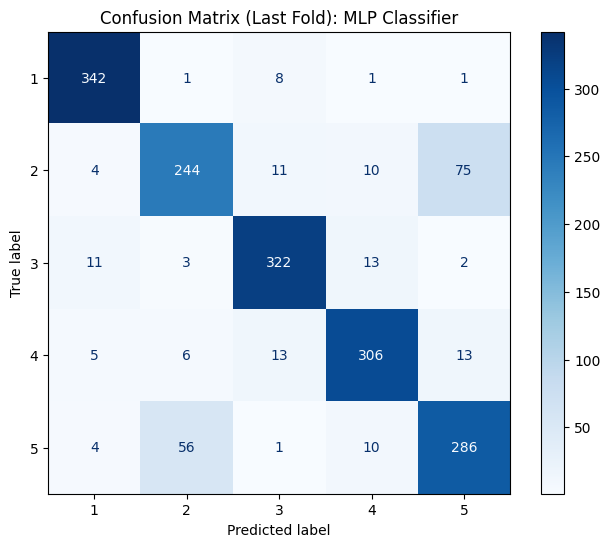

 training: Naive Bayes
Mean Accuracy (CV): 0.7638
Max Single Fold Accuracy: 0.7752
Best Params: {}

--- Results for Last Fold (Fold 5) ---
              precision    recall  f1-score   support

           1       0.89      0.92      0.90       353
           2       0.70      0.57      0.63       344
           3       0.78      0.79      0.79       351
           4       0.79      0.81      0.80       343
           5       0.67      0.74      0.70       357

    accuracy                           0.77      1748
   macro avg       0.77      0.77      0.76      1748
weighted avg       0.77      0.77      0.76      1748

Accuracy per class (Last Fold):
   Class 1: 0.9150
   Class 2: 0.5698
   Class 3: 0.7949
   Class 4: 0.8134
   Class 5: 0.7395


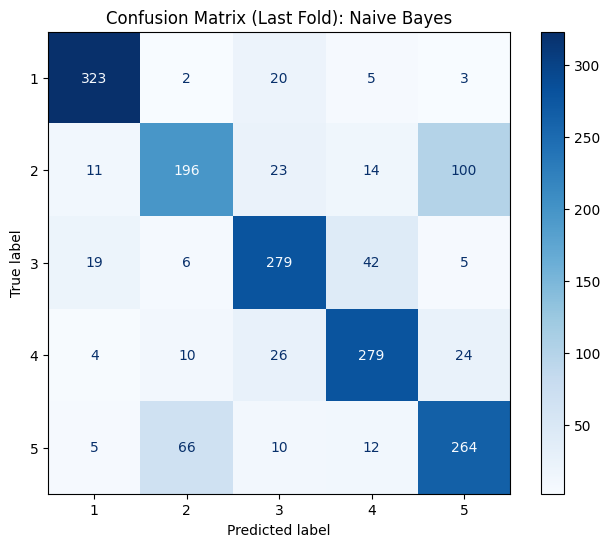

 training: SVM (Custom RBF)
Mean Accuracy (CV): 0.8748
Max Single Fold Accuracy: 0.8907
Best Params: {'clf__C': 1.5, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

--- Results for Last Fold (Fold 5) ---
              precision    recall  f1-score   support

           1       0.96      0.99      0.97       353
           2       0.82      0.73      0.77       344
           3       0.94      0.96      0.95       351
           4       0.96      0.91      0.93       343
           5       0.78      0.86      0.82       357

    accuracy                           0.89      1748
   macro avg       0.89      0.89      0.89      1748
weighted avg       0.89      0.89      0.89      1748

Accuracy per class (Last Fold):
   Class 1: 0.9858
   Class 2: 0.7326
   Class 3: 0.9630
   Class 4: 0.9067
   Class 5: 0.8627


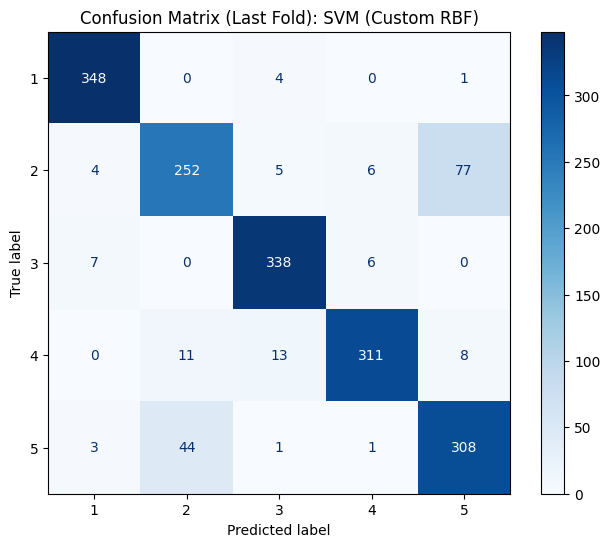

 training: SVM (Poly Kernel)
Mean Accuracy (CV): 0.8710
Max Single Fold Accuracy: 0.8873
Best Params: {'clf__C': 1.5, 'clf__degree': 3, 'clf__kernel': 'poly'}

--- Results for Last Fold (Fold 5) ---
              precision    recall  f1-score   support

           1       0.97      0.97      0.97       353
           2       0.84      0.72      0.78       344
           3       0.93      0.95      0.94       351
           4       0.97      0.90      0.93       343
           5       0.76      0.89      0.82       357

    accuracy                           0.89      1748
   macro avg       0.89      0.89      0.89      1748
weighted avg       0.89      0.89      0.89      1748

Accuracy per class (Last Fold):
   Class 1: 0.9688
   Class 2: 0.7238
   Class 3: 0.9487
   Class 4: 0.9009
   Class 5: 0.8908


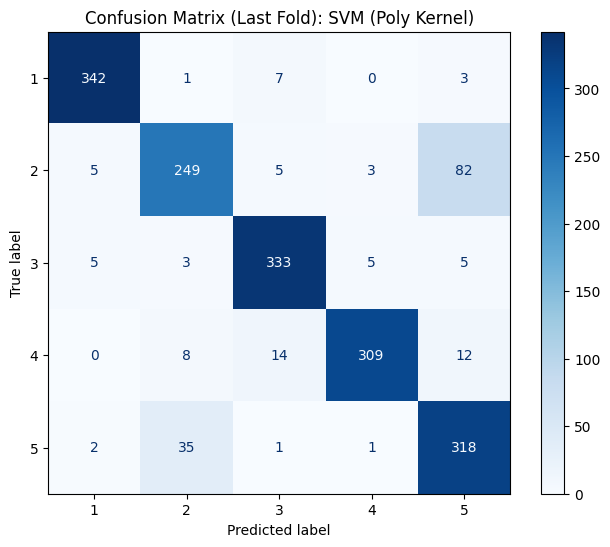

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Tools
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# classifiers
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# preprocessing
train_df = pd.read_csv('datasetTV.csv', header=None)
X = train_df.iloc[:, :-1].values
y = train_df.iloc[:, -1].values

# test set loading
test_df = pd.read_csv('datasetTest.csv', header=None)
X_test_final = test_df.values

print(f" Training Data loaded: {X.shape}")
print(f" Test Data loaded: {X_test_final.shape}")

# fine-tuning the parameters of every classifier
model_configs = []

# MLP Classifier
model_configs.append((
    "MLP Classifier",
    MLPClassifier(random_state=42, early_stopping=True),
    {
        'clf__hidden_layer_sizes': [(400,)],
        'clf__activation': ['relu'],
        'clf__solver': ['adam'],
        'clf__learning_rate_init': [0.001],
        'clf__max_iter': [1055]
    }
))

# Naive Bayes
model_configs.append((
    "Naive Bayes",
    GaussianNB(),
    {}
))

# SVM - rbf kernel
model_configs.append((
    "SVM (Custom RBF)",
    SVC(probability=True),
    {
        'clf__C': [1.5],
        'clf__kernel': ['rbf'],
        'clf__gamma': ['scale']
    }
))

# SVM - poly kernel
model_configs.append((
    "SVM (Poly Kernel)",
    SVC(),
    {
        'clf__kernel': ['poly'],
        'clf__degree': [3],
        'clf__C': [1.5]
    }
))

#train and evaluate
best_global_score = -1
best_global_model = None
best_global_name = ""

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model, params in model_configs:

    print(f" training: {name}")


    # Pipeline (Scaling -> PCA -> Model)
    pipe = Pipeline([
        ('scaler', MinMaxScaler()),
        ('pca', PCA(n_components=0.8)), # 0.8 of variance
        ('clf', model)
    ])

    # Grid Search
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=params,
        cv=kfold,
        scoring='accuracy',
        n_jobs=-1,
        refit=True
    )



    grid.fit(X, y)

    if name == "SVM (Custom RBF)":



        # 6955 samples

        test_predictions = grid.best_estimator_.predict(X_test_final)





        np.save('labels27.npy', test_predictions)



    # Εξαγωγή του Max Accuracy από όλα τα folds
    best_index = grid.best_index_
    # Παίρνουμε τα scores και για τα 5 splits για τις συγκεκριμένες παραμέτρους
    fold_scores = [grid.cv_results_[f"split{i}_test_score"][best_index] for i in range(5)]
    max_acc = np.max(fold_scores)
    mean_acc = grid.best_score_

    print(f"Mean Accuracy (CV): {mean_acc:.4f}")
    print(f"Max Single Fold Accuracy: {max_acc:.4f}") # <--- Αυτό που ζήτησες
    print(f"Best Params: {grid.best_params_}")

    # Απομόνωση του τελευταίου fold για το Confusion Matrix
    folds = list(kfold.split(X, y))
    train_idx, test_idx = folds[-1]

    X_train_fold, X_test_fold = X[train_idx], X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]

    # Εκπαίδευση με τις καλύτερες παραμέτρους στο training κομμάτι του τελευταίου split
    best_model_fold = grid.best_estimator_
    best_model_fold.fit(X_train_fold, y_train_fold)
    y_pred_fold = best_model_fold.predict(X_test_fold)

    # Εκτύπωση αποτελεσμάτων για το τελευταίο fold
    print(f"\n--- Results for Last Fold (Fold 5) ---")
    print(classification_report(y_test_fold, y_pred_fold))

    cm_fold = confusion_matrix(y_test_fold, y_pred_fold)

    # Accuracy ανά κλάση
    acc_per_class = cm_fold.diagonal() / cm_fold.sum(axis=1)
    print("Accuracy per class (Last Fold):")
    for i, acc in enumerate(acc_per_class, start=1):
        print(f"   Class {i}: {acc:.4f}")

    # Οπτικοποίηση
    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_fold, display_labels=[1, 2, 3, 4, 5])
    disp.plot(cmap='Blues', ax=plt.gca())
    plt.title(f'Confusion Matrix (Last Fold): {name}')
    plt.show()



In [ ]:
import numpy as np

# Loading data from labels27
labels = np.load('labels27.npy')

# length of labels
print(f"Labels' length : {labels.shape}")

# Classes
print(f"Classes : {np.unique(labels)}")

# 10 first predictions
print(f"First Predictions : {labels[:10]}")

Labels' length : (6955,)
Classes : [1 2 3 4 5]
First Predictions : [1 4 5 2 5 4 5 5 1 3]


###Δεδομένα μετά την κανονικοποίηση και την PCA.

In [ ]:

scaler = MinMaxScaler()
pca = PCA(n_components=0.8)

# Εφαρμογή Κανονικοποίησης (Scaling)
X_scaled = scaler.fit_transform(X)

# Εφαρμογή PCA
X_pca = pca.fit_transform(X_scaled)

# Μετατροπή σε DataFrame για ευανάγνωστη προβολή
X_pca_df = pd.DataFrame(X_pca)

# Προβολή των πρώτων γραμμών
print("Δεδομένα μετά το PCA:", X_pca.shape)
print("\nΟι πρώτες 5 γραμμές των μετασχηματισμένων δεδομένων:")
print(X_pca_df.head())
print(f"Αρχικές στήλες: {X.shape[1]}")
print(f"Στήλες μετά το PCA: {X_pca.shape[1]}")


Δεδομένα μετά το PCA: (8743, 123)

Οι πρώτες 5 γραμμές των μετασχηματισμένων δεδομένων:
        0         1         2         3         4         5         6    \
0  1.195073 -0.300117  0.234634 -0.274491  0.173899 -0.348595 -0.136414   
1  0.203141  0.019003 -0.149718 -0.193716 -0.547775  0.636873 -0.219577   
2 -0.420826 -0.024324 -0.767942 -0.095956  0.245184 -0.440803 -0.536148   
3 -0.529471  0.224530  0.060983 -0.328325 -0.192962 -0.290194  0.301808   
4  0.013228  0.589942  0.071380  0.155972  0.243957 -0.504453 -0.132487   

        7         8         9    ...       113       114       115       116  \
0  0.187026  0.058238 -0.323103  ...  0.017945 -0.168500 -0.122243  0.130705   
1  0.638810 -0.377035  0.194183  ...  0.018378  0.061058  0.082281 -0.139882   
2 -0.124796  0.257627  0.065424  ...  0.106743  0.055909 -0.013505  0.028831   
3  0.104342  0.090267  0.616313  ... -0.077327 -0.096514  0.047498 -0.058495   
4  0.343102  0.200636 -0.395259  ... -0.068069  0.119633  0.1

#ΕΞΑΓΩΓΗ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΜΕ MLP ΚΑΙ ΤΑΞΙΝΟΜΗΣΗ ΜΕ SVM
Πραγματοποιήθηκε πείραμα με χρήση νευρωνικού δικτύου (MLP) ως εξαγωγέα χαρακτηριστικών (Deep Feature Extraction). Το μοντέλο εκπαιδεύτηκε να μετατρέπει τα αρχικά 224 χαρακτηριστικά σε ένα διάνυσμα 420 διαστάσεων μέσω ενός dense layer.
###Προεπεξεργασία δεδομένων
* Διαχωρισμός δεδομένων του συνόλου εκπαίδευσης σε 80% δείγματα εκπαίδευσης και 20% δείγματα ελέγχου, με stratify προκειμένου να διασφαλιστεί ότι η αναλογία των κλάσεων (π.χ. πόσα δείγματα έχει η Κλάση 2 και πόσα η 5) παραμένει ίδια και στα δύο σύνολα, αποφεύγοντας έτσι την μεροληψία του μοντέλου.
* Κανονικοποίηση με MinMaxScaler() στο εύρος [0,1], διότι τα νευρωνικά δίκτυα είναι ευαίσθητα στις μεγάλες τιμές. Αν ένα χαρακτηριστικό έχει τιμές από 1000 έως 2000 και ένα άλλο από 0 έως 1, το μοντέλο θα "νομίζει" ότι το πρώτο είναι πιο σημαντικό, ενώ στην πραγματικότητα δεν είναι.
* One hot encoding για μετατροπή των αριθμών των κλάσεων σε διανύσματα δυαδικής μορφής. Αυτό είναι απαραίτητο για το τελευταίο επίπεδο του Νευρωνικού Δικτύου (Softmax layer), το οποίο υπολογίζει πιθανότητες για κάθε κλάση ξεχωριστά.
### Αρχιτεκτονική και εκπαίδευση
* Επίπεδο εισόδου και κρυφό επίπεδο: Το δίκτυο δέχεται 224 εισόδους (input_dim), που αντιστοιχούν στα χαρακτηριστικά των δεδομένων.
Χρησιμοποιεί 420 νευρώνες για την αναγνώριση περίπλοκων προτύπων.

* Activation = 'relu': Επιτρέπει στο δίκτυο να μαθαίνει μη γραμμικές σχέσεις.

* Kernel Initializer = 'he_normal': Μια βέλτιστη μέθοδος αρχικοποίησης των βαρών για επίπεδα ReLU, που βοηθά στη σταθερότητα της εκπαίδευσης και την ταχύτερη σύγκλιση.
* Dropout Layer: Σε κάθε βήμα εκπαίδευσης, το 45% των νευρώνων απενεργοποιείται τυχαία, αναγκάζοντας το δίκτυο να μην βασίζεται σε συγκεκριμένους νευρώνες και άρα να γενικεύει καλύτερα (αποφυγή υπερεκπαίδευσης).
* Επίπεδο εξόδου : Αποτελείται από 5 νευρώνες, όσοι και οι κλάσεις του προβλήματος. Η συνάρτηση ενεργοποίησης είναι η softmax και μετατρέπει τις εξόδους σε πιθανότητες που αθροίζουν στο 1.0 (π.χ. 80% πιθανότητα για την Κλάση 1).
* Συνάρτηση σφάλματος : Cross Entropy Function για προβλήματα ταξινόμησης πολλών κλάσεων όταν χρησιμοποιείται one-hot encoding. Μετράει την "απόσταση" μεταξύ της πρόβλεψης και της πραγματικής κλάσης.
* Adam Optimizer : Είναι ο αλγόριθμος που αποφασίζει πώς θα αλλάξουν τα βάρη των νευρώνων ώστε να μειωθεί το σφάλμα της πρόβλεψης. Προσαρμόζει τον ρυθμό μάθησης για κάθε βάρος ξεχωριστά ώστε να βρει το ολικό ελάχιστο της συνάρτησης σφάλματος.
* Early Stopping : Αν η ακρίβεια στο validation set (val_accuracy) σταματήσει να βελτιώνεται για 25 συνεχόμενες εποχές, η εκπαίδευση διακόπτεται αυτόματα.
* Batch Size : Το μοντέλο βλέπει 70 δείγματα τη φορά πριν ενημερώσει τα βάρη του.
* H εκπαίδευση έχει οριστεί στις 100 εποχές, ωστόσο διακόπτεται νωρίτερα από το μηχανισμό early stopping.
###Ταξινόμηση με SVM
Το προτελευταίο επίπεδο (το last_dropout) περιέχει την ουσία της πληροφορίας σε μια μορφή που το δίκτυο θεωρεί ιδανική για να ξεχωρίσει τις κλάσεις. Τα αρχικά 224 χαρακτηριστικά του datasetTV.csv μετατρέπονται σε 420 νέα χαρακτηριστικά (όσα και οι νευρώνες του Dense layer). Αυτές τροφοδοτούνται σε ένα SVM με RBF πυρήνα, με αυξημένη παράμετρο κανονικοποίησης $C=2$ που το επιτρέπει να χαράζει εξαιρετικά πολύπλοκα και μη γραμμικά σύνορα απόφασης σε αυτόν τον νέο πολυδιάστατο χώρο, επιτυγχάνοντας μια πιο αυστηρή και ακριβή οριοθέτηση των κλάσεων σε σχέση με τις πιθανοτικές προσεγγίσεις των MLP (από την softmax). Αυτή η γεωμετρική προσέγγιση στην ταξινόμηση, σε συνδυασμό με την αυτόματη ρύθμιση gamma='scale', επιτρέπει στο μοντέλο να εκμεταλλεύεται τη διασπορά των 420 νευρώνων για να επιλύει τις ασάφειες στις περιοχές έντονης επικάλυψης—όπως αυτή των κλάσεων 2 και 5(όπως φαίνεται και από το confusion matrix)—οδηγώντας στην επίτευξη της ακρίβειας του 87,25% στο validation set. Παρατηρούμε πως η ακρίβεια του SVM είναι 2.5% μεγαλύτερη από αυτή του MLP μοντέλου. Αυτό δείχνει ότι το τελευταίο επίπεδο του MLP έχει βελτιωμένη αναπαράσταση των χαρακτηριστικών , ενώ το SVM προσπαθεί να βρει ακόμα και σε αυτό το επίπεδο της μη γραμμικές σχέσεις.

###Καμπύλες Μάθησης MLP
Στις πρώτες 20-30 εποχές, παρατηρούμε μια απότομη άνοδο και στις δύο καμπύλες (Train και Val Acc), γεγονός που δείχνει ότι το μοντέλο εντοπίζει γρήγορα τα βασικά μοτίβα των δεδομένων. Η καμπύλη του Validation Accuracy σταθεροποιείται  γύρω στην εποχή 40, χωρίς να μπορεί να ξεπεράσει το όριο του 85%. Αυτό δείχνει ότι το σκέτο MLP περιορίζεται σε αυτή την επίδοση λόγω της πολυπλοκότητας του προβλήματος. Μετά την εποχή 40, η ακρίβεια εκπαίδευσης συνεχίζει να ανεβαίνει προς το 0.90, ενώ η ακρίβεια επικύρωσης παραμένει στάσιμη. Η validation accuracy παρουσιάζει έντονα spikes (noise). Αυτό υποδηλώνει ότι ο αλγόριθμος Adam δυσκολεύεται να βρει ένα σταθερό ελάχιστο στην περιοχή επικάλυψης των κλάσεων 2 και 5, κάτι που το SVM με τον RBF kernel διαχειρίζεται πολύ πιο ομαλά.

Loading data...
Training MLP to learn features...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 - 4s - 39ms/step - accuracy: 0.5591 - loss: 1.0786 - val_accuracy: 0.7341 - val_loss: 0.7458 - learning_rate: 0.0017
Epoch 2/100
100/100 - 0s - 3ms/step - accuracy: 0.6989 - loss: 0.7768 - val_accuracy: 0.7364 - val_loss: 0.6539 - learning_rate: 0.0017
Epoch 3/100
100/100 - 0s - 3ms/step - accuracy: 0.7232 - loss: 0.7125 - val_accuracy: 0.7307 - val_loss: 0.6672 - learning_rate: 0.0017
Epoch 4/100
100/100 - 0s - 3ms/step - accuracy: 0.7326 - loss: 0.6742 - val_accuracy: 0.7873 - val_loss: 0.5704 - learning_rate: 0.0017
Epoch 5/100
100/100 - 0s - 3ms/step - accuracy: 0.7534 - loss: 0.6452 - val_accuracy: 0.7724 - val_loss: 0.5850 - learning_rate: 0.0017
Epoch 6/100
100/100 - 0s - 3ms/step - accuracy: 0.7574 - loss: 0.6188 - val_accuracy: 0.7799 - val_loss: 0.5640 - learning_rate: 0.0017
Epoch 7/100
100/100 - 0s - 3ms/step - accuracy: 0.7691 - loss: 0.6099 - val_accuracy: 0.7982 - val_loss: 0.5227 - learning_rate: 0.0017
Epoch 8/100
100/100 - 0s - 3ms/step - accuracy: 0.7722 - lo

<Figure size 800x800 with 0 Axes>

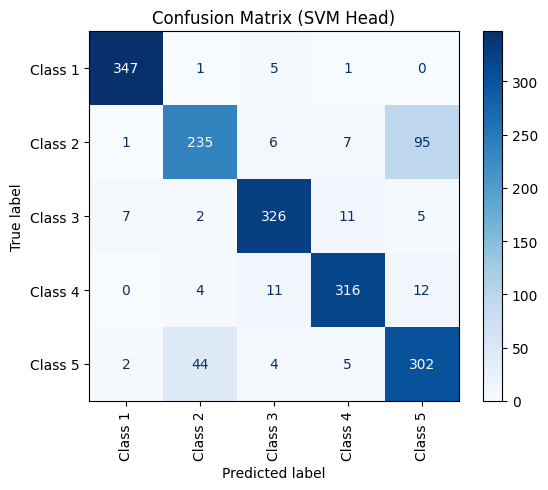

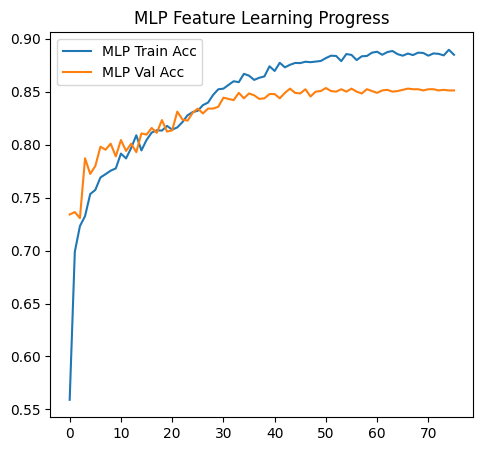


--- Generating Final SVM Predictions ---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from tensorflow.keras.models import Sequential, Model # Προσθήκη Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.utils import to_categorical
from sklearn.svm import SVC # Προσθήκη SVM
from tensorflow.keras.layers import GaussianNoise

# Φόρτωση Δεδομένων
print("Loading data...")
train_df = pd.read_csv('datasetTV.csv', header=None)
test_submit_df = pd.read_csv('datasetTest.csv', header=None)

X = train_df.iloc[:, :-1].values
y = train_df.iloc[:, -1].values

#  Προετοιμασία Δεδομένων
# Τα labels είναι 1-5, αλλά το Keras απαιτεί 0-4.
y_adjusted = y - 1

labels_names = ['Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5']

# Διαχωρισμός
x_train, x_val, y_train, y_val = train_test_split(X, y_adjusted, test_size=0.2, random_state=42, stratify=y_adjusted)

# Scaling
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test_submit = scaler.transform(test_submit_df.values)



# One-hot encoding (Χρειάζεται για την εκπαίδευση του MLP)
y_train_onehot = to_categorical(y_train, 5)
y_val_onehot = to_categorical(y_val, 5)


# Το εκπαιδεύουμε ως classifier πρώτα για να μάθει τα βάρη
model = Sequential([
    # Input Layer
    Dense(420, input_dim=224, activation='relu', kernel_initializer='he_normal', name='dense_1'),
    Dropout(0.45, name='last_dropout'), #prin 0.4
    # Output layer (Θα το αγνοήσει το SVM αργότερα)
    Dense(5, activation='softmax', name='output_layer')
])

model.compile(optimizer=Adam(learning_rate=0.0017), #prin 0.0015
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])

#  Callbacks
early_stopping = EarlyStopping(monitor='val_accuracy', patience=25, restore_best_weights=True)

def learning_rate_scheduler(epoch, lr):
    if epoch < 25:
        return float(lr)
    else:
        return float(lr * tf.math.exp(-0.1))

lr_scheduler = LearningRateScheduler(learning_rate_scheduler)

#  Εκπαίδευση MLP (για να μάθει τα features)
print("Training MLP to learn features...")
history = model.fit(
    x_train, y_train_onehot,
    epochs=100,
    batch_size=70,
    validation_data=(x_val, y_val_onehot),
    callbacks=[early_stopping, lr_scheduler],
    verbose=2
)

# Feature Extraction & SVM Training
print("\nExtracting Features and Training SVM Head")

# Δημιουργούμε ένα νέο μοντέλο που σταματάει πριν το τελευταίο Dense(5)
# Παίρνουμε την έξοδο του layer 'last_dropout'
feature_extractor = Model(inputs=model.inputs, outputs=model.get_layer('last_dropout').output)
train_features = feature_extractor.predict(x_train)
val_features = feature_extractor.predict(x_val)
test_features_final = feature_extractor.predict(x_test_submit)

print(f"New Feature Shape: {train_features.shape}") # Πρέπει να είναι (rows, 128)

# Ορισμός και Εκπαίδευση SVM
svm_head = SVC(kernel='rbf', C=2, gamma='scale') #5.6 best so far
print("Fitting SVM...")
# Το SVM θέλει τα labels ως 1D array (y_train), όχι one-hot
svm_head.fit(train_features, y_train)

#  Αξιολόγηση SVM
print("Evaluating SVM on Validation Set...")
svm_pred_val = svm_head.predict(val_features)
svm_acc = accuracy_score(y_val, svm_pred_val)

print(f"\n>>> SVM Validation Accuracy: {svm_acc * 100:.2f}% <<<")

# Confusion Matrix για το SVM
cm = confusion_matrix(y_val, svm_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_names)
plt.figure(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Confusion Matrix (SVM Head)")
plt.show()

# MLP Training Curves
# Είναι χρήσιμο να δούμε αν το MLP έμαθε καλά, άσχετα που χρησιμοποιούμε SVM
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='MLP Train Acc')
plt.plot(history.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Feature Learning Progress')
plt.legend()
plt.show()


# Πρόβλεψη στο Test set χρησιμοποιώντας τα features και το SVM
final_preds_svm = svm_head.predict(test_features_final)

# Μετατροπή των labels πίσω σε 1-5 (επειδή είχαμε κάνει y - 1 στην αρχή)
final_preds_ready = final_preds_svm + 1
